| Column Name      | Type                         |
| ---------------- | ---------------------------- |
| customerID       | ID                           |
| gender           | Categorical                  |
| SeniorCitizen    | Numerical                    |
| Partner          | Categorical                  |
| Dependents       | Categorical                  |
| tenure           | Numerical                    |
| PhoneService     | Categorical                  |
| MultipleLines    | Categorical                  |
| InternetService  | Categorical                  |
| OnlineSecurity   | Categorical                  |
| OnlineBackup     | Categorical                  |
| DeviceProtection | Categorical                  |
| TechSupport      | Categorical                  |
| StreamingTV      | Categorical                  |
| StreamingMovies  | Categorical                  |
| Contract         | Categorical                  |
| PaperlessBilling | Categorical                  |
| PaymentMethod    | Categorical                  |
| MonthlyCharges   | Numerical                    |
| TotalCharges     | Numerical (needs conversion) |
| Churn            | Target                       |


# Step 1: Import Required Libraries

In [3]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Model
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation
from sklearn.metrics import(
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Step 2: Load Dataset

In [5]:
df = pd.read_csv("GB_WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)

df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Step 3: Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Step 4: Check Missing Values

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Step 5: Convert TotalCharges to Numeric

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

df['TotalCharges'].isnull().sum()

11

# Step 6: Fill Missing Values

In [12]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace = True)

# Step 7: Drop Customer ID

In [15]:
df.drop('customerID', axis = 1, inplace = True)

# Step 8: Target Variable Distribution

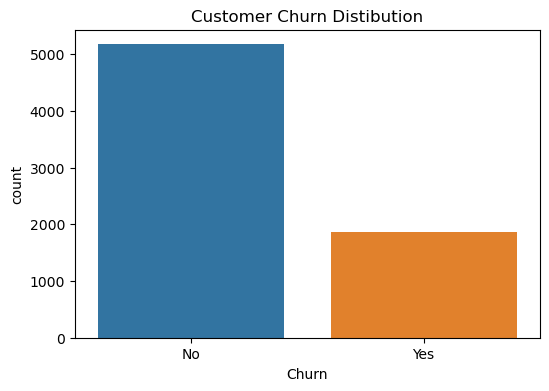

In [19]:
plt.figure(figsize = (6,4))
           
sns.countplot(x = 'Churn', data = df)
           
plt.title("Customer Churn Distibution")
           
plt.show()

# Step 9: Churn Percentage Chart

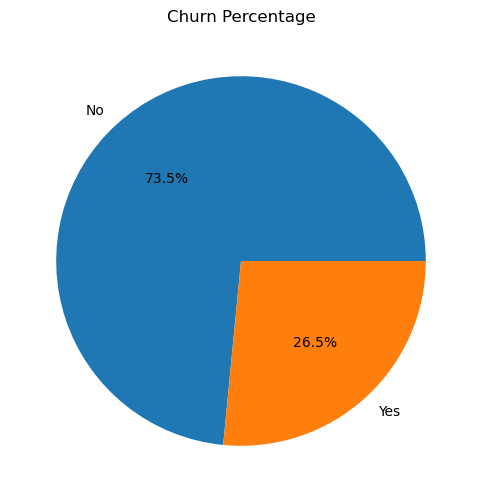

In [23]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize = (6,6))

plt.pie(
    churn_counts,
    labels = churn_counts.index,
    autopct = '%1.1f%%'
)

plt.title("Churn Percentage")

plt.show()

# Step 10: Numerical Features Distribution

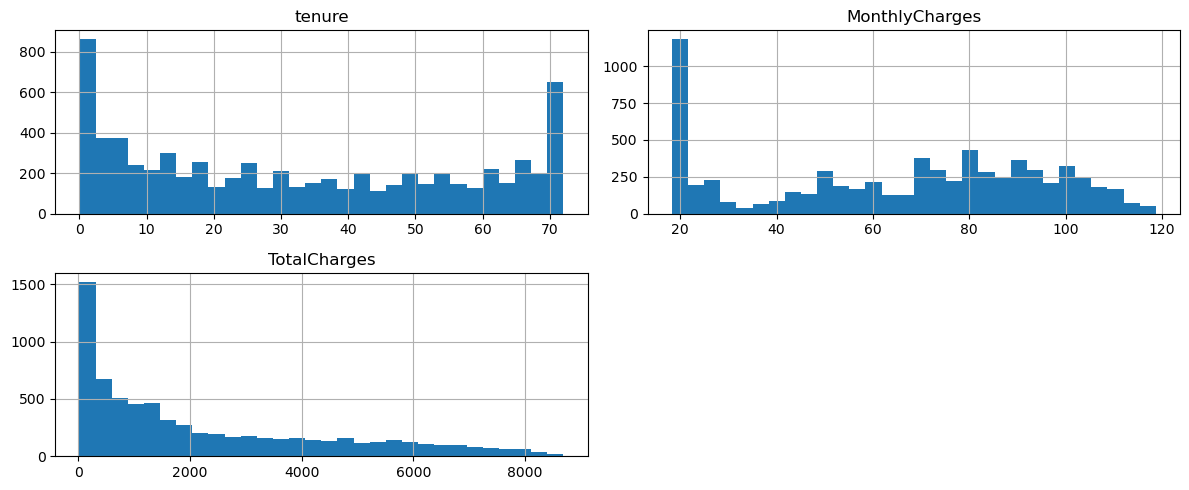

In [24]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

df[num_cols].hist(
    figsize = (12,5),
    bins = 30
)

plt.tight_layout()
plt.show()

# Step 11: Correlation Heatmap

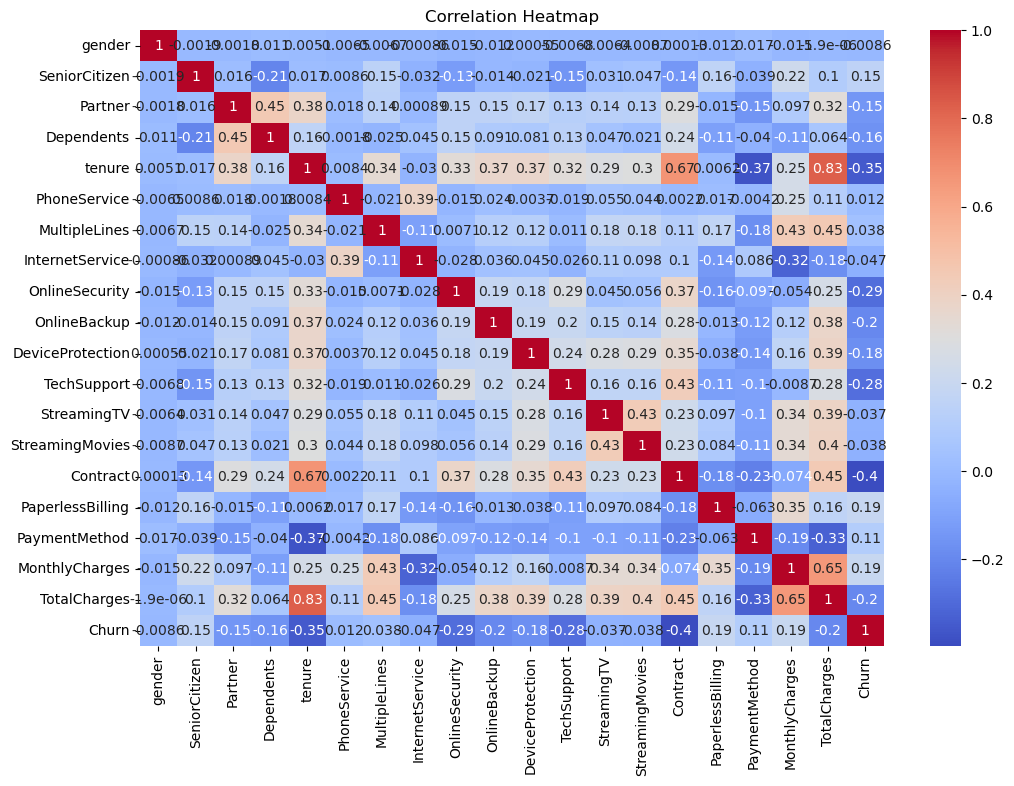

In [28]:
temp_df = df.copy()

le = LabelEncoder()

for col in temp_df.columns:
    if temp_df[col].dtype == 'object':
        temp_df[col] = le.fit_transform(temp_df[col])
        
plt.figure(figsize = (12,8))

sns.heatmap(
    temp_df.corr(),
    annot = True,
    cmap = 'coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# Step 12: Encode Categorical Variables

In [29]:
df_encoded = pd.get_dummies(df,drop_first = True)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


# Step 13: Define X and y

In [30]:
X = df_encoded.drop('Churn_Yes', axis = 1)

y = df_encoded['Churn_Yes']

# Step 14: Train Test Split

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

print(X_train.shape)
print(X_test.shape)

(5634, 30)
(1409, 30)


# Step 15: Build Gradient Boosting Model

In [33]:
gb_model = GradientBoostingClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 3,
    random_state = 42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

# Step 16: Prediction

In [38]:
y_pred = gb_model.predict(X_test)

y_prob = gb_model.predict_proba(X_test)[:,1]

print(y_pred)
print(y_prob)

[0 1 0 ... 0 0 0]
[0.02228531 0.82834482 0.05521402 ... 0.11018388 0.02004887 0.01442593]


# Step 17: Accuracy Score

In [39]:
accuracy = accuracy_score(
    y_test, y_pred
)

print("Accuracy :", round(accuracy*100,2), '%')

Accuracy : 79.84 %


# Step 18: Confusion Matrix

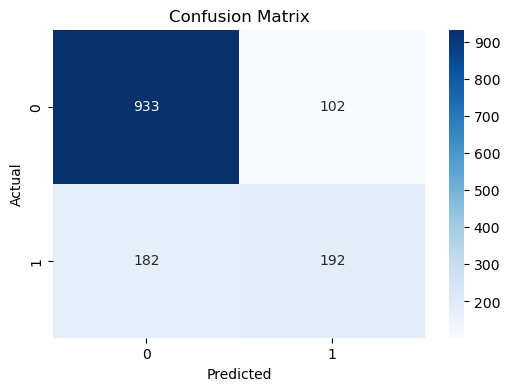

In [41]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6,4))

sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Step 19: Classification Report

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.51      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



# Step 20: ROC Curve

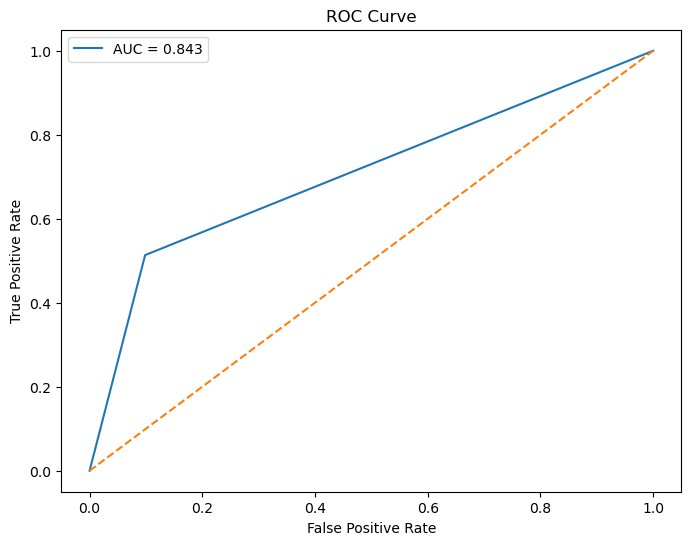

In [43]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize = (8,6))

plt.plot(fpr, tpr, label = f"AUC = {auc_score:.3f}")

plt.plot([0,1], [0,1], '--')

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

# Step 21: Feature Importance

In [44]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb_model.feature_importances_
})

importance = importance.sort_values(
    by = 'Importance',
    ascending = False
)

importance.head(15)

,Feature,Importance
1,tenure,0.291500
10,InternetService_Fiber optic,0.192732
28,PaymentMethod_Electronic check,0.125032
25,Contract_Two year,0.074660
3,TotalCharges,0.070882
24,Contract_One year,0.059233
2,MonthlyCharges,0.054573
26,PaperlessBilling_Yes,0.023167
13,OnlineSecurity_Yes,0.015332
14,OnlineBackup_No internet service,0.013227


# Step 22: Top 15 Important Features Graph

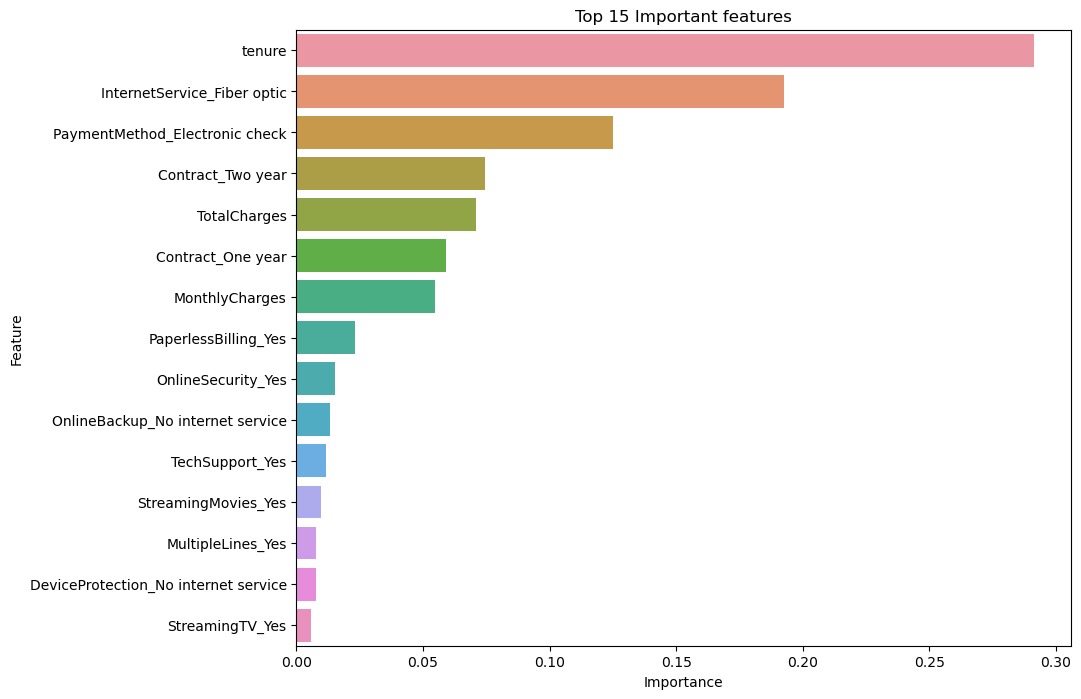

In [47]:
plt.figure(figsize = (10,8))

sns.barplot(
    x = 'Importance',
    y = 'Feature',
    data = importance.head(15)
)

plt.title("Top 15 Important features")

plt.show()

# Step 23: Training Accuracy

In [49]:
train_pred = gb_model.predict(X_train)

train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy :", train_acc)

Training Accuracy : 0.8271210507632233


# Step 24: Testing Accuracy

In [52]:
test_acc = accuracy_score(y_pred, y_pred)

print("Testing Accuracy :", test_acc)

Testing Accuracy : 1.0


# Step 25: Overfitting Check

In [53]:
print("Training Accuracy :", round(train_acc*100,2))

print("Testing Accuaracy :", round(test_acc*100,2))

difference = train_acc - test_acc

print("Difference :", round(difference*100,2))

Training Accuracy : 82.71
Testing Accuaracy : 100.0
Difference : -17.29


# Step 26: Actual vs Predicted

In [54]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted' : y_pred
})

results.head(20)

,Actual,Predicted
437,0,0
2280,0,1
2235,0,0
4460,0,0
3761,0,0
5748,0,1
3568,0,0
2976,0,0
5928,0,0
1639,1,0


# Step 27: Save Model (Optional)

In [56]:
import joblib

joblib.dump(
    gb_model,
    "GradientBoosting_TelcoChurn.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


# Important Gradient Boosting Parameters

| Parameter         | Meaning               |
| ----------------- | --------------------- |
| n_estimators      | Number of Trees       |
| learning_rate     | Learning Speed        |
| max_depth         | Tree Depth            |
| subsample         | Random Sampling       |
| min_samples_split | Minimum Split Samples |
| min_samples_leaf  | Minimum Leaf Samples  |
| random_state      | Reproducibility       |
